In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.exceptions import ConvergenceWarning

from pickle import dump

import warnings
warnings.simplefilter(action = "ignore", category = RuntimeWarning)
warnings.simplefilter(action = "ignore", category = ConvergenceWarning)

In [2]:
df = pd.read_csv("heart disease classification dataset.csv")
df.shape

(303, 15)

In [3]:
df["sex"] = df["sex"].map({"male": 1, "female": 0})
df["target"] = df["target"].map({"yes": 1, "no": 0})

In [4]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
4,4,57,0,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,1


In [5]:
df.tail()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,298,57,0,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,0
299,299,45,1,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,0
300,300,68,1,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,0
301,301,57,1,0,NaN,131.0,0,1,115.0,1,1.2,1,1,3,0
302,302,57,0,1,130.0,236.0,0,0,174.0,0,0.0,1,1,2,0


In [6]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

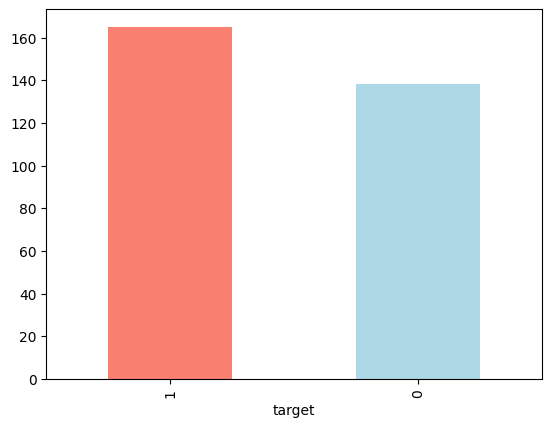

In [7]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"]);

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    int64  
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    int64  
dtypes: float64(4), int64(11)
memory usage: 35.6 KB


In [9]:
df.isna().sum()

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      4
chol          1
fbs           0
restecg       0
thalach       5
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.isna().sum()

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64

In [12]:
df.describe()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000
mean,150.877133,54.348123,0.689420,0.965870,131.679181,246.177474,0.146758,0.518771,149.880546,0.331058,1.054266,1.392491,0.730375,2.320819,0.546075
std,86.860137,9.182042,0.463523,1.033114,17.658077,51.405545,0.354470,0.527162,22.638525,0.471399,1.173169,0.618946,1.029862,0.613331,0.498724
min,0.000000,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,47.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,134.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,151.000000,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,226.000000,61.000000,1.000000,2.000000,140.000000,275.000000,0.000000,1.000000,167.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,302.000000,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [13]:
df.sex.value_counts()

sex
1    202
0     91
Name: count, dtype: int64

In [14]:
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,23,110
1,68,92


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

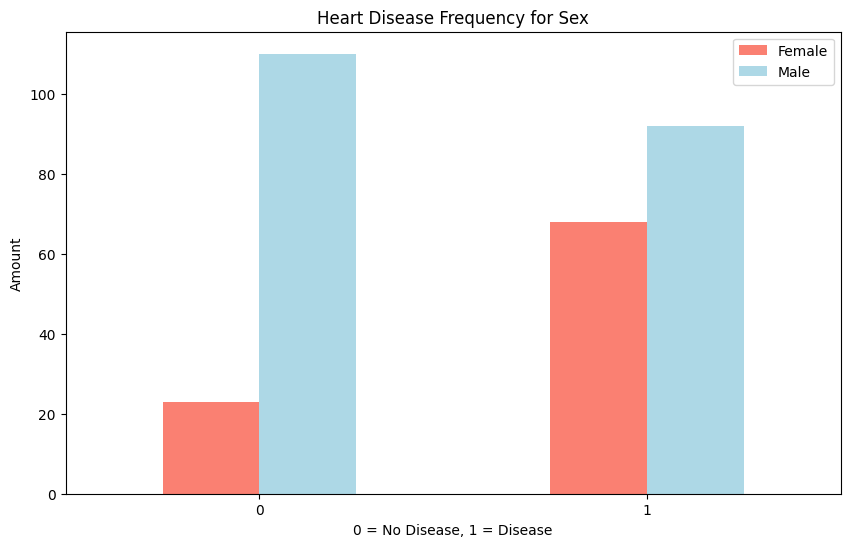

In [15]:
pd.crosstab(df.target, df.sex).plot(kind="bar", 
                                    figsize=(10, 6),
                                    color=["salmon", "lightblue"])

plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"]);
plt.xticks(rotation=0)

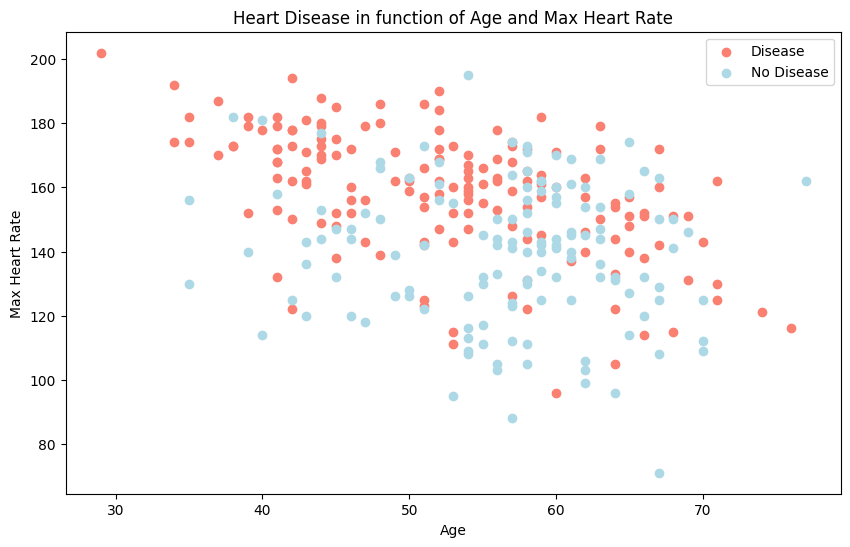

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(df.age[df.target == 1],
            df.thalach[df.target == 1],
            c="salmon")

plt.scatter(df.age[df.target == 0],
            df.thalach[df.target == 0],
            c="lightblue")

plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

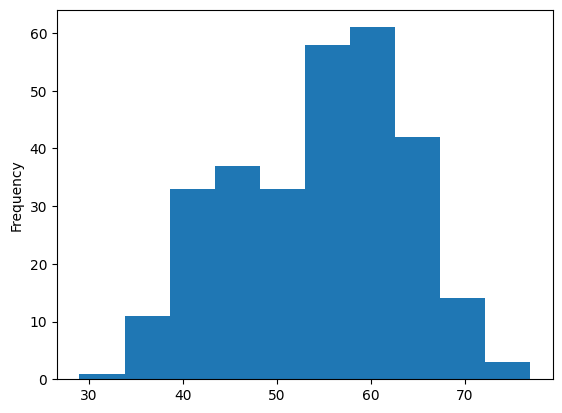

In [17]:
df.age.plot.hist();

In [18]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,101,37
1,9,41
2,16,66
3,7,16


(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

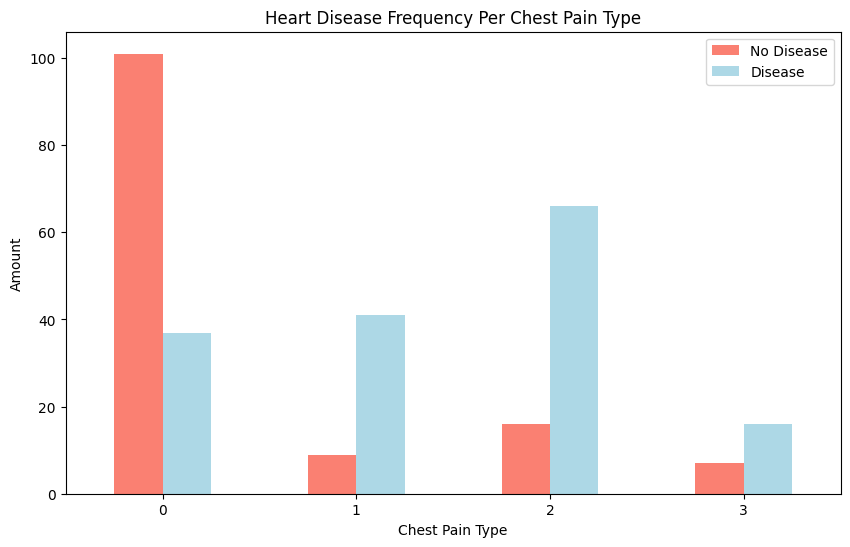

In [19]:
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10, 6),
                                   color=["salmon", "lightblue"])

plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0)

In [20]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
5,5,57,1,0,140.0,192.0,0,1,148.0,0,0.4,1,0,1,1


In [21]:
df.corr()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
Unnamed: 0,1.000000,0.179975,0.181503,-0.398856,0.098182,0.051948,-0.008088,-0.019919,-0.391267,0.378961,0.307510,-0.274223,0.380823,0.264371,-0.862056
age,0.179975,1.000000,-0.104863,-0.070586,0.276586,0.216155,0.127349,-0.119509,-0.396884,0.095919,0.211278,-0.167542,0.280493,0.067060,-0.215905
sex,0.181503,-0.104863,1.000000,-0.043666,-0.068282,-0.189984,0.028242,-0.053143,-0.045322,0.143038,0.099115,-0.027255,0.103767,0.219176,-0.271211
cp,-0.398856,-0.070586,-0.043666,1.000000,0.051210,-0.091003,0.097889,0.045198,0.302782,-0.391609,-0.153591,0.122779,-0.182492,-0.171826,0.441747
trestbps,0.098182,0.276586,-0.068282,0.051210,1.000000,0.135529,0.168406,-0.102731,-0.028102,0.072459,0.193254,-0.115657,0.096166,0.073411,-0.139090
chol,0.051948,0.216155,-0.189984,-0.091003,0.135529,1.000000,0.026193,-0.166307,-0.038738,0.071904,0.066434,-0.026953,0.089595,0.106809,-0.103311
fbs,-0.008088,0.127349,0.028242,0.097889,0.168406,0.026193,1.000000,-0.078938,0.001339,0.036164,0.009607,-0.060520,0.118146,-0.012527,-0.028695
restecg,-0.019919,-0.119509,-0.053143,0.045198,-0.102731,-0.166307,-0.078938,1.000000,0.038211,-0.073327,-0.051767,0.087550,-0.069496,-0.018690,0.143242
thalach,-0.391267,-0.396884,-0.045322,0.302782,-0.028102,-0.038738,0.001339,0.038211,1.000000,-0.395491,-0.347278,0.379258,-0.207472,-0.099342,0.411950
exang,0.378961,0.095919,0.143038,-0.391609,0.072459,0.071904,0.036164,-0.073327,-0.395491,1.000000,0.286938,-0.259066,0.121005,0.199949,-0.451127


(15.5, -0.5)

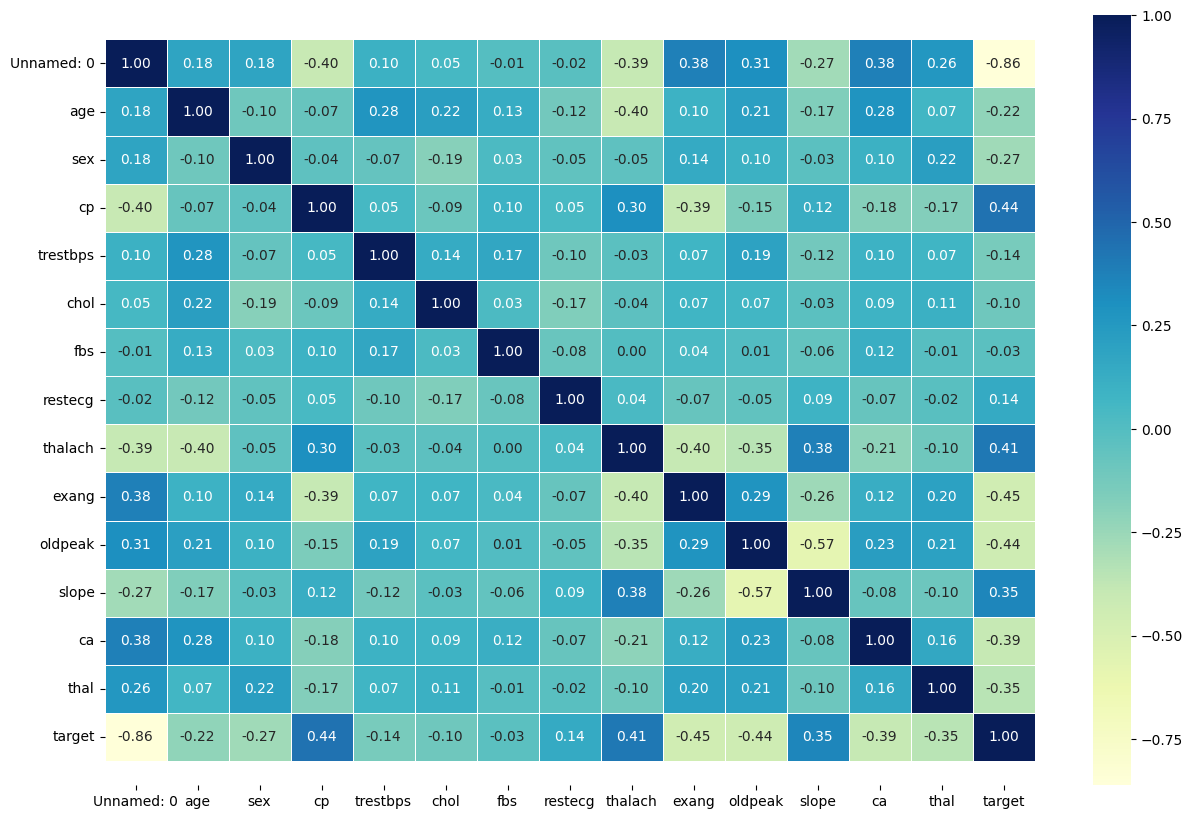

In [23]:
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidth=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

In [24]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
5,5,57,1,0,140.0,192.0,0,1,148.0,0,0.4,1,0,1,1


In [25]:
X = df.drop("target", axis=1)
y = df["target"]

In [26]:
X

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2
5,5,57,1,0,140.0,192.0,0,1,148.0,0,0.4,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,296,63,0,0,124.0,197.0,0,1,136.0,1,0.0,1,0,2
298,298,57,0,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3
299,299,45,1,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3
300,300,68,1,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3


In [27]:
y

0      1
1      1
2      1
3      1
5      1
      ..
296    0
298    0
299    0
300    0
302    0
Name: target, Length: 293, dtype: int64

In [28]:
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [29]:
X_train

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
217,217,63,1,0,130.0,330.0,1,0,132.0,1,1.8,2,3,3
236,236,58,1,0,125.0,300.0,0,0,171.0,0,0.0,2,2,3
233,233,64,1,0,120.0,246.0,0,0,96.0,1,2.2,0,1,2
76,76,51,1,2,125.0,245.0,1,0,166.0,0,2.4,1,0,2
27,27,51,1,2,110.0,175.0,0,1,123.0,0,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,194,60,1,2,140.0,185.0,0,0,155.0,0,3.0,1,0,2
74,74,43,0,2,122.0,213.0,0,1,165.0,0,0.2,1,0,2
110,110,64,0,0,180.0,325.0,0,1,154.0,1,0.0,2,0,2
278,278,58,0,1,136.0,319.0,1,0,152.0,0,0.0,2,2,2


In [30]:
y_train, len(y_train)

(217    0
 236    0
 233    0
 76     1
 27     1
       ..
 194    0
 74     1
 110    1
 278    0
 106    1
 Name: target, Length: 234, dtype: int64,
 234)

In [31]:
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

def fit_and_score(models, X_train, X_test, y_train, y_test):
    np.random.seed(42)
    model_scores = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [32]:
model_scores = fit_and_score(
    models=models,
    X_train=X_train, 
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

model_scores

{'Logistic Regression': 0.9830508474576272, 'KNN': 1.0, 'Random Forest': 1.0}

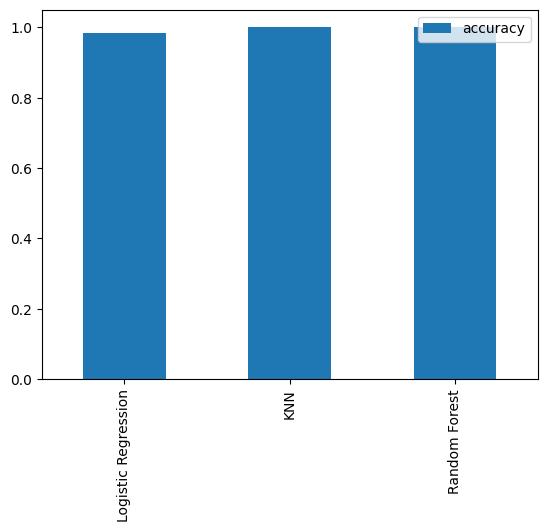

In [33]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();

In [39]:

train_scores = []
test_scores = []

# Create a list of differnt values for n_neighbors
neighbors = range(1, 21)

# Setup KNN instance
knn = KNeighborsClassifier()

# Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)
    
    # Fit the algorithm
    knn.fit(X_train, y_train)
    
    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))
    
    # Update the test scores list
    test_scores.append(knn.score(X_test, y_test))

In [40]:
train_scores

[1.0,
 0.9786324786324786,
 1.0,
 0.9871794871794872,
 0.9786324786324786,
 0.9871794871794872,
 0.9829059829059829,
 0.9829059829059829,
 0.9914529914529915,
 0.9871794871794872,
 0.9871794871794872,
 0.9871794871794872,
 0.9871794871794872,
 0.9871794871794872,
 0.9829059829059829,
 0.9871794871794872,
 0.9829059829059829,
 0.9871794871794872,
 0.9871794871794872,
 0.9871794871794872]

In [41]:
test_scores

[0.9491525423728814,
 0.9830508474576272,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9830508474576272,
 0.9830508474576272,
 0.9830508474576272,
 0.9830508474576272,
 0.9830508474576272,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

Maximum KNN score on the test data: 100.00%


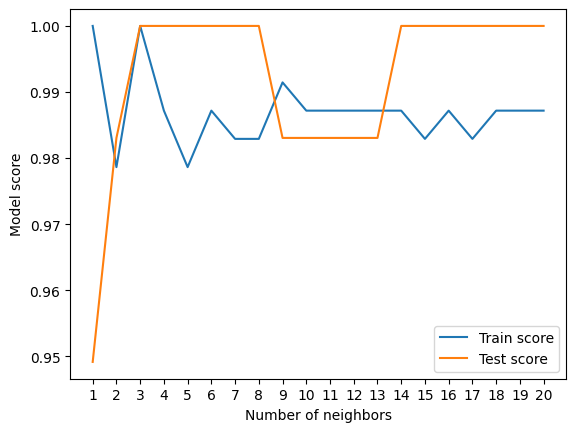

In [42]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores) * 100:.2f}%")

In [43]:
# Create a hyperparameter grid for LogisticRegression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# Create a hyperparameter grid for RandomForestClassifier
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}


In [44]:
np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [45]:
rs_log_reg.best_params_


{'solver': 'liblinear', 'C': 0.615848211066026}

In [46]:
rs_log_reg.score(X_test, y_test)


0.9830508474576272

In [47]:
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(), 
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

# Fit random hyperparameter search model for RandomForestClassifier()
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [48]:
rs_rf.best_params_

{'n_estimators': 610,
 'min_samples_split': 18,
 'min_samples_leaf': 1,
 'max_depth': 5}

In [49]:
rs_rf.score(X_test, y_test)

1.0

In [50]:
log_reg_grid = {"C": np.logspace(-4, 4, 30),
                "solver": ["liblinear"]}

# Setup grid hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

# Fit grid hyperparameter search model
gs_log_reg.fit(X_train, y_train);


Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [51]:
gs_log_reg.best_params_

{'C': 0.38566204211634725, 'solver': 'liblinear'}

In [52]:
gs_log_reg.score(X_test, y_test)

0.9830508474576272

In [53]:
y_preds = gs_log_reg.predict(X_test)

In [54]:
y_preds

array([1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1])

In [55]:
y_test

87     1
268    0
47     1
182    0
148    1
129    1
234    0
122    1
10     1
94     1
152    1
283    0
35     1
289    0
228    0
80     1
48     1
6      1
238    0
251    0
128    1
245    0
287    0
105    1
78     1
279    0
282    0
113    1
63     1
208    0
44     1
59     1
293    0
121    1
62     1
170    0
290    0
117    1
164    1
66     1
151    1
69     1
277    0
163    1
187    0
32     1
24     1
26     1
285    0
123    1
253    0
82     1
19     1
178    0
220    0
183    0
189    0
173    0
7      1
Name: target, dtype: int64

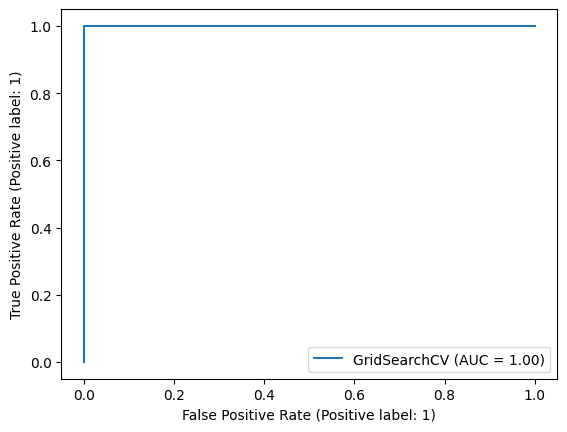

In [56]:
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)

In [57]:
print(confusion_matrix(y_test, y_preds))

[[24  1]
 [ 0 34]]


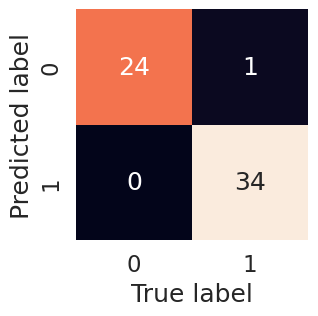

In [59]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")

    bottom, top = ax.get_ylim()

plot_conf_mat(y_test, y_preds)

In [60]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        25
           1       0.97      1.00      0.99        34

    accuracy                           0.98        59
   macro avg       0.99      0.98      0.98        59
weighted avg       0.98      0.98      0.98        59



In [61]:
gs_log_reg.best_params_

{'C': 0.38566204211634725, 'solver': 'liblinear'}

In [62]:
clf = LogisticRegression(C = 0.38566204211634725,
                         solver = "liblinear")

In [63]:
cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="accuracy")

cv_acc

array([0.86440678, 1.        , 1.        , 1.        , 0.70689655])

In [64]:
cv_acc = np.mean(cv_acc)
cv_acc

0.9142606662770308

In [65]:
cv_precision = cross_val_score(clf,
                               X,
                               y,
                               cv=5, 
                               scoring="precision")

cv_precision=np.mean(cv_precision)
cv_precision

0.96

In [69]:
cv_recall = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="recall")
cv_recall = np.mean(cv_recall)
cv_recall

0.89375

In [70]:
cv_f1 = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring="f1"
)

cv_f1 = np.mean(cv_f1)
cv_f1

0.905437352245863

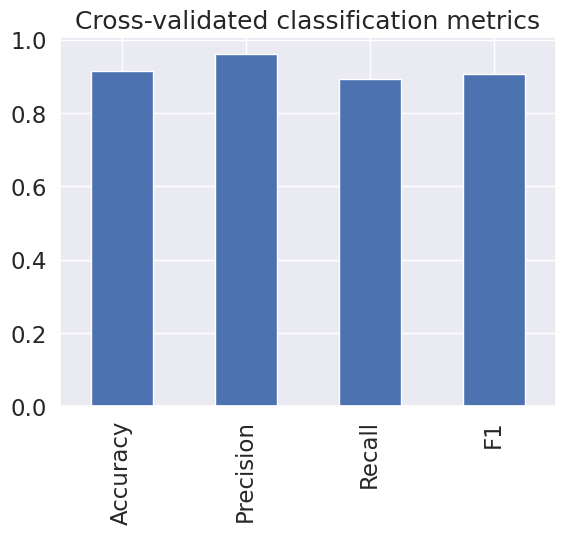

In [71]:
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                           "Precision": cv_precision,
                           "Recall": cv_recall,
                           "F1": cv_f1},
                         index=[0])

cv_metrics.T.plot.bar(title="Cross-validated classification metrics", legend=False);

In [72]:
clf = LogisticRegression(C=0.20433597178569418,
                         solver="liblinear")

clf.fit(X_train, y_train)

LogisticRegression(C=0.20433597178569418, solver='liblinear')

In [73]:
clf.coef_

array([[-0.30539423,  0.20423013,  0.00224858,  0.2360241 ,  0.14660957,
        -0.01902622, -0.034549  ,  0.29024279,  0.16051147, -0.02432079,
        -0.603413  ,  0.28566599, -0.10020767,  0.00192227]])

In [74]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
5,5,57,1,0,140.0,192.0,0,1,148.0,0,0.4,1,0,1,1


In [75]:
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'Unnamed: 0': -0.30539423277183897,
 'age': 0.20423013080849,
 'sex': 0.002248576762371889,
 'cp': 0.23602409594480833,
 'trestbps': 0.1466095718681162,
 'chol': -0.01902622161161616,
 'fbs': -0.03454899611473391,
 'restecg': 0.2902427871453178,
 'thalach': 0.1605114680305127,
 'exang': -0.0243207859421929,
 'oldpeak': -0.6034130031236316,
 'slope': 0.2856659883317292,
 'ca': -0.10020766501049792,
 'thal': 0.0019222735933100438}

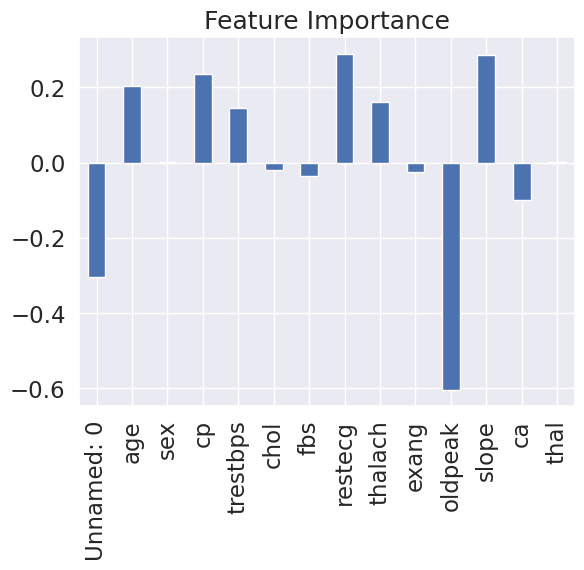

In [76]:
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title="Feature Importance", legend=False);